In [1]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# Loading the datasets
Top_df = pd.read_excel('TopSoil_Compiled EDXFR Results_Orginal.xlsx') # Topsoil profile dataset
Sub_df = pd.read_excel('SubSoil_Compiled EDXFR Results_Orginal.xlsx') # Subsoil profile dataset
Combined_df = pd.read_csv('Top_Sub_File.csv') # Dataset contains subsoil with corresponding topsoil analysis results

In [3]:
Combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Lab. No     39 non-null     int64  
 1   Field No    39 non-null     object 
 2   SampleSite  39 non-null     object 
 3   Line        39 non-null     int64  
 4   lat         39 non-null     float64
 5   lon         39 non-null     float64
 6   Elev(m)     39 non-null     float64
 7   dES(m)      39 non-null     float64
 8   dRD(m)      39 non-null     float64
 9   Top_pH      39 non-null     float64
 10  Sub_pH      39 non-null     float64
 11  Top_OM      39 non-null     float64
 12  Sub_OM      39 non-null     float64
 13  Top_Fe      39 non-null     float64
 14  Sub_Fe      39 non-null     float64
 15  Top_Cu      39 non-null     float64
 16  Sub_Cu      39 non-null     float64
 17  Top_Zn      39 non-null     float64
 18  Sub_Zn      39 non-null     float64
 19  Top_Cd      39 non-null     flo

In [4]:
dfT = pd.DataFrame()
dfS = pd.DataFrame()
dfC = Combined_df.copy()

# Top Soil Layer
dfT[['As','Cd','Pb','Zn','Cu','Fe']] = Top_df[['As (mg/kg)','Cd (mg/kg)','Pb (mg/kg)','Zn (mg/kg)', 'Cu (mg/kg)','Fe (mg/kg)']]

# Sub Soil Layer
dfS[['As','Cd','Pb','Zn','Cu','Fe']] = Sub_df[['As (mg/kg)','Cd (mg/kg)','Pb (mg/kg)','Zn (mg/kg)', 'Cu (mg/kg)','Fe (mg/kg)']]

# Combined Top&Sub Soil Layers (Dropping columns that are not needed)
dfC = dfC.drop(columns=['Lab. No','Field No','SampleSite','Line','lat','lon','Elev(m)','dES(m)','dRD(m)','Top_Hg','Sub_Hg'])


In [5]:
dfC = dfC[['Top_pH','Sub_pH','Top_OM','Sub_OM','Top_As','Sub_As','Top_Cd','Sub_Cd','Top_Pb ','Sub_Pb','Top_Zn','Sub_Zn',
           'Top_Cu','Sub_Cu','Top_Fe','Sub_Fe']]

In [6]:
# Create a colormap that is fully transparent
transparent_cmap = LinearSegmentedColormap.from_list("transparent", [(1,1,1,0), (1,1,1,0)])


## 1. TopSoil Correlation

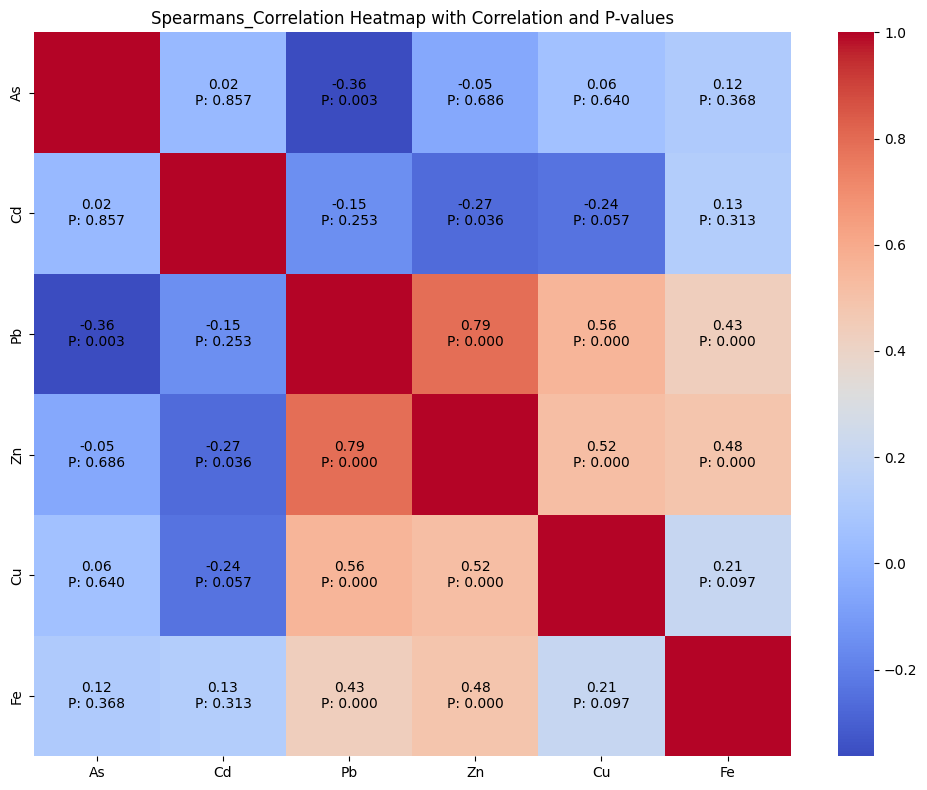

In [7]:
# Create empty matrices for correlation coefficients and p-values
columns = dfT.columns
corr_matrix = np.zeros((len(columns), len(columns)))
p_value_matrix = np.zeros((len(columns), len(columns)))

# Compute the Pearson correlation and p-values for each pair of columns
for i in range(len(columns)):
    for j in range(i, len(columns)):  # Avoid redundant calculations by starting from i
        col1, col2 = columns[i], columns[j]
        corr, p_value = spearmanr(dfT[col1], dfT[col2])
        corr_matrix[i, j] = corr_matrix[j, i] = corr  # Correlation is symmetric
        p_value_matrix[i, j] = p_value_matrix[j, i] = p_value  # P-values are symmetric

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', xticklabels=columns, yticklabels=columns)

# Add annotations for both correlation and p-value in each cell
for i in range(len(columns)):
    for j in range(len(columns)):
        if i != j:  # Avoid annotating the diagonal
            corr = corr_matrix[i, j]
            p_value = p_value_matrix[i, j]
            # Format the text to show both correlation and p-value
            text = f'{corr:.2f}\nP: {p_value:.3f}'
            plt.text(j + 0.5, i + 0.5, text, ha='center', va='center', color='black', fontsize=10)

# Add title and show the plot
plt.title("Spearmans_Correlation Heatmap with Correlation and P-values")
plt.tight_layout()
plt.show()

#### Creating the lower half of the correlation heatmap to display pairwise relationships among variables while avoiding redundant values from the upper half. The created Transparent colormap is used

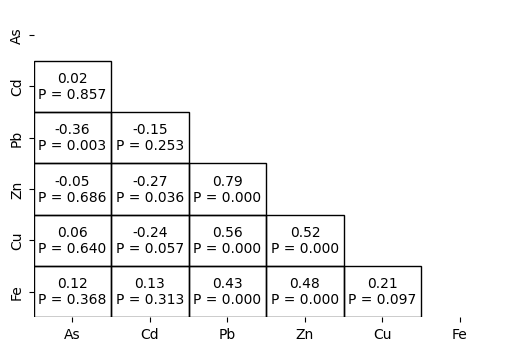

In [8]:
# Transparent colormap used
columns = dfT.columns
n = len(columns)

# Compute correlation and p-values
corr_matrix = np.zeros((n, n))
p_value_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(i, n):
        col1, col2 = columns[i], columns[j]
        corr, p_value = spearmanr(dfT[col1], dfT[col2])
        corr_matrix[i, j] = corr_matrix[j, i] = corr
        p_value_matrix[i, j] = p_value_matrix[j, i] = p_value

# Upper-triangle mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap with fully transparent cells and no Seaborn borders
plt.figure(figsize=(6, 4))
ax = sns.heatmap(
    corr_matrix,
    annot=False,
    cmap=transparent_cmap,
    linewidths=0,  # turn off default borders
    cbar=False,
    xticklabels=columns,
    yticklabels=columns,
    mask=mask
)

# Draw borders manually only for visible (unmasked) cells
for i in range(n):
    for j in range(n):
        if not mask[i, j]:
            rect = plt.Rectangle(
                (j, i), 1, 1, fill=False, edgecolor='black', lw=1
            )
            ax.add_patch(rect)
            # Optional: annotate lower triangle
            if i > j:
                corr = corr_matrix[i, j]
                p = p_value_matrix[i, j]
                text = f"{corr:.2f}\nP = {p:.3f}"
                ax.text(j + 0.5, i + 0.5, text, ha='center', va='center', color='black', fontsize=10)

# Saving the figure in both PNG and PDF formats
plt.savefig("TopSoilCorreHeatmap_Spearmans.pdf",dpi=300, bbox_inches="tight")
plt.savefig("TopSoilCorreHeatmap_Spearmans.png",dpi=300, bbox_inches="tight")
plt.show()

## 2. SubSoil Correlation

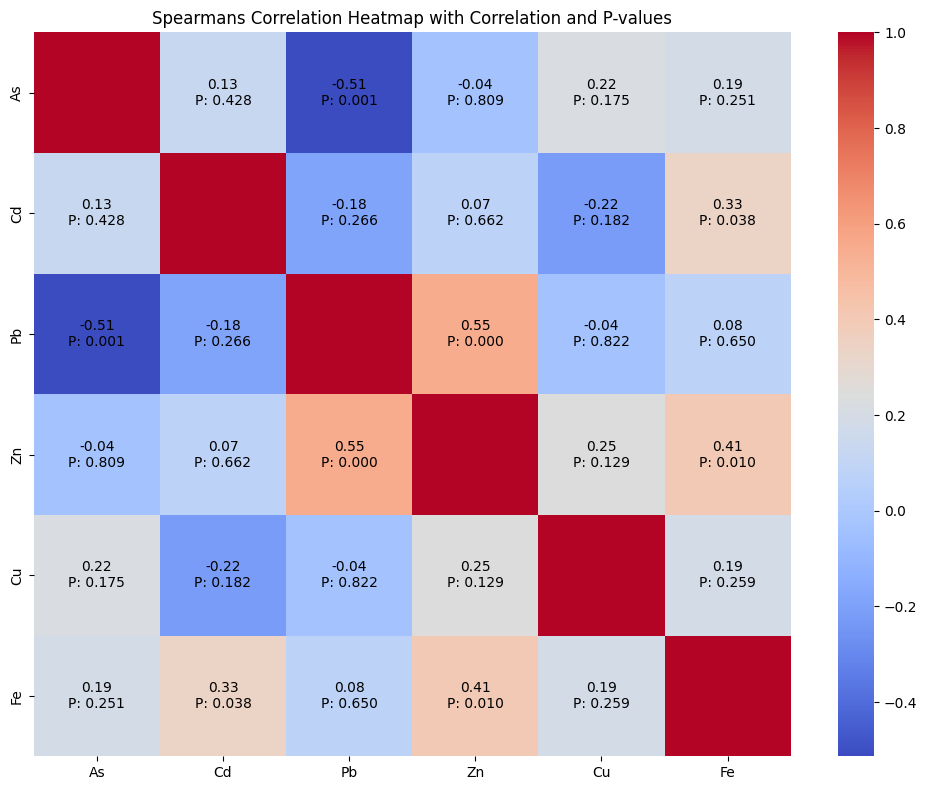

In [9]:
# Create empty matrices for correlation coefficients and p-values
columns = dfS.columns
corr_matrix = np.zeros((len(columns), len(columns)))
p_value_matrix = np.zeros((len(columns), len(columns)))

# Compute the Pearson correlation and p-values for each pair of columns
for i in range(len(columns)):
    for j in range(i, len(columns)):  # Avoid redundant calculations by starting from i
        col1, col2 = columns[i], columns[j]
        corr, p_value = spearmanr(dfS[col1], dfS[col2])
        corr_matrix[i, j] = corr_matrix[j, i] = corr  # Correlation is symmetric
        p_value_matrix[i, j] = p_value_matrix[j, i] = p_value  # P-values are symmetric

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', xticklabels=columns, yticklabels=columns)

# Add annotations for both correlation and p-value in each cell
for i in range(len(columns)):
    for j in range(len(columns)):
        if i != j:  # Avoid annotating the diagonal
            corr = corr_matrix[i, j]
            p_value = p_value_matrix[i, j]
            # Format the text to show both correlation and p-value
            text = f'{corr:.2f}\nP: {p_value:.3f}'
            plt.text(j + 0.5, i + 0.5, text, ha='center', va='center', color='black', fontsize=10)

# Add title and show the plot
plt.title("Spearmans Correlation Heatmap with Correlation and P-values")
plt.tight_layout()
plt.show()

#### Creating the lower half of the correlation heatmap to display pairwise relationships among variables while avoiding redundant values from the upper half. The created Transparent colormap is used.

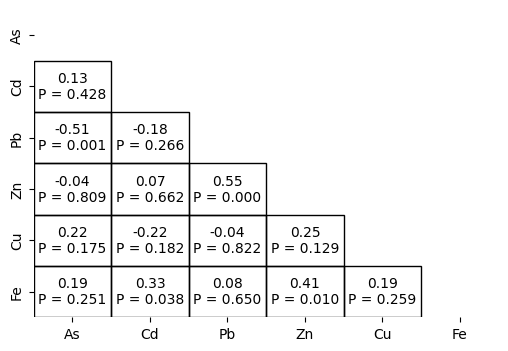

In [10]:
# Transparent colormap used

columns = dfS.columns
n = len(columns)

# Compute correlation and p-values
corr_matrix = np.zeros((n, n))
p_value_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(i, n):
        col1, col2 = columns[i], columns[j]
        corr, p_value = spearmanr(dfS[col1], dfS[col2])
        corr_matrix[i, j] = corr_matrix[j, i] = corr
        p_value_matrix[i, j] = p_value_matrix[j, i] = p_value

# Upper-triangle mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap with fully transparent cells and no Seaborn borders
plt.figure(figsize=(6, 4))
ax = sns.heatmap(
    corr_matrix,
    annot=False,
    cmap=transparent_cmap,
    linewidths=0,  # turn off default borders
    cbar=False,
    xticklabels=columns, # 
    yticklabels=columns,
    mask=mask,
)

# Draw borders manually only for visible (unmasked) cells
for i in range(n):
    for j in range(n):
        if not mask[i, j]:
            rect = plt.Rectangle(
                (j, i), 1, 1, fill=False, edgecolor='black', lw=1
            )
            ax.add_patch(rect)
            # Optional: annotate lower triangle
            if i > j:
                corr = corr_matrix[i, j]
                p = p_value_matrix[i, j]
                text = f"{corr:.2f}\nP = {p:.3f}"
                ax.text(j + 0.5, i + 0.5, text, ha='center', va='center', color='black', fontsize=10)

# Saving the figure in both PNG and PDF formats
plt.savefig("SubSoilCorreHeatmap_Spearmans.pdf",dpi=300, bbox_inches="tight")
plt.savefig("SubSoilCorreHeatmap_Spearmans.png",dpi=300, bbox_inches="tight")
plt.show()

## 3. Top and Sub Soil Comparsion Correlation

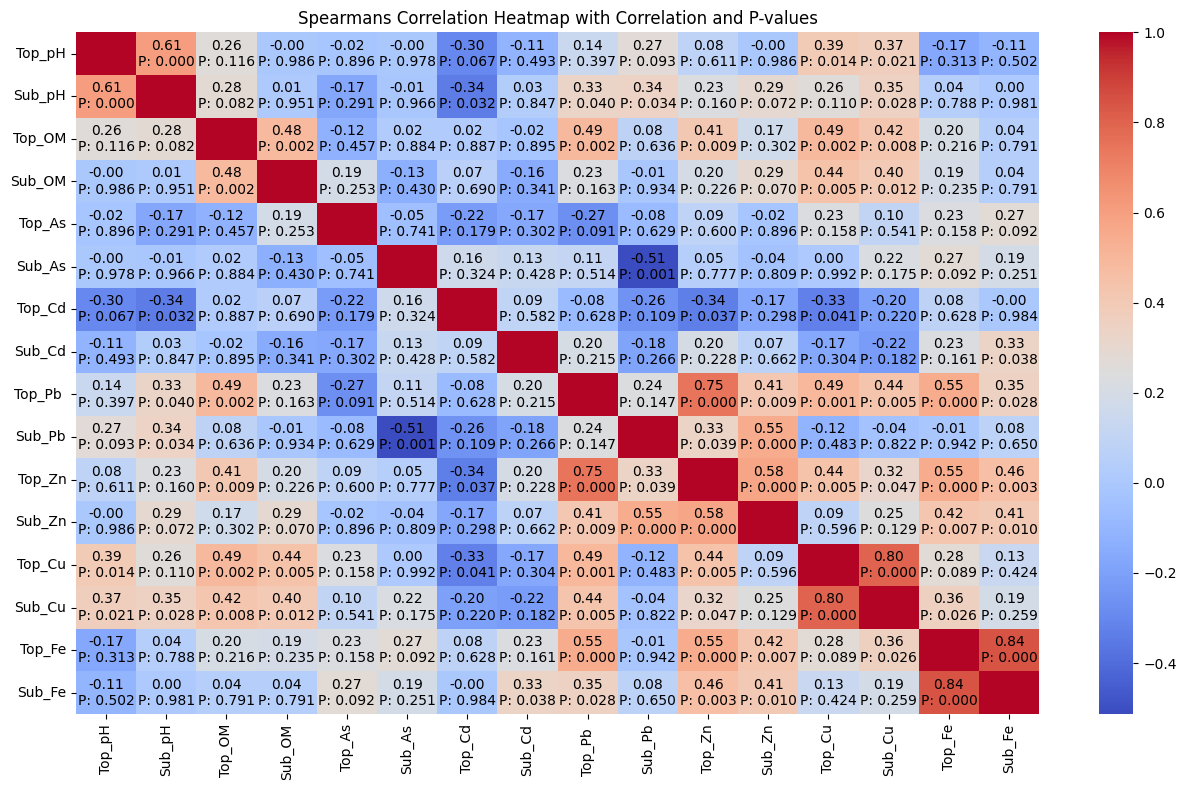

In [11]:
# Create empty matrices for correlation coefficients and p-values
columns = dfC.columns
corr_matrix = np.zeros((len(columns), len(columns)))
p_value_matrix = np.zeros((len(columns), len(columns)))

# Compute the Pearson correlation and p-values for each pair of columns
for i in range(len(columns)):
    for j in range(i, len(columns)):  # Avoid redundant calculations by starting from i
        col1, col2 = columns[i], columns[j]
        corr, p_value = spearmanr(dfC[col1], dfC[col2])
        corr_matrix[i, j] = corr_matrix[j, i] = corr  # Correlation is symmetric
        p_value_matrix[i, j] = p_value_matrix[j, i] = p_value  # P-values are symmetric

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(13, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', xticklabels=columns, yticklabels=columns)

# Add annotations for both correlation and p-value in each cell
for i in range(len(columns)):
    for j in range(len(columns)):
        if i != j:  # Avoid annotating the diagonal
            corr = corr_matrix[i, j]
            p_value = p_value_matrix[i, j]
            # Format the text to show both correlation and p-value
            text = f'{corr:.2f}\nP: {p_value:.3f}'
            plt.text(j + 0.5, i + 0.5, text, ha='center', va='center', color='black', fontsize=10)

# Add title and show the plot
plt.title("Spearmans Correlation Heatmap with Correlation and P-values")
plt.tight_layout()
plt.show()

#### Creating the lower half of the correlation heatmap to display pairwise relationships among variables while avoiding redundant values from the upper half. The created Transparent colormap is used.

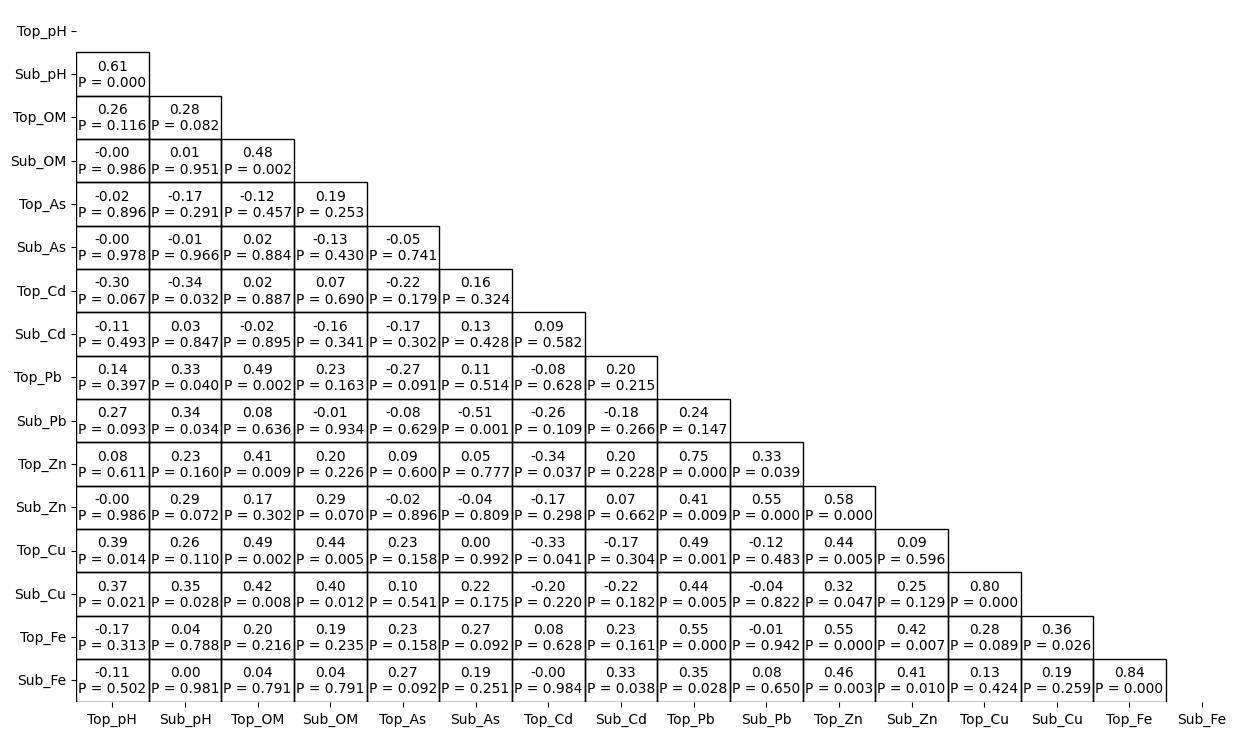

In [12]:
# Transparent colormap used
columns = dfC.columns
n = len(columns)

# Compute correlation and p-values
corr_matrix = np.zeros((n, n))
p_value_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(i, n):
        col1, col2 = columns[i], columns[j]
        corr, p_value = spearmanr(dfC[col1], dfC[col2])
        corr_matrix[i, j] = corr_matrix[j, i] = corr
        p_value_matrix[i, j] = p_value_matrix[j, i] = p_value

# Upper-triangle mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap with fully transparent cells and no Seaborn borders
plt.figure(figsize=(15, 9))
ax = sns.heatmap(
    corr_matrix,
    annot=False,
    cmap=transparent_cmap,
    linewidths=0,  # turn off default borders
    cbar=False,
    xticklabels=columns,
    yticklabels=columns,
    mask=mask
)

# Draw borders manually only for visible (unmasked) cells
for i in range(n):
    for j in range(n):
        if not mask[i, j]:
            rect = plt.Rectangle(
                (j, i), 1, 1, fill=False, edgecolor='black', lw=1
            )
            ax.add_patch(rect)
            # Optional: annotate lower triangle
            if i > j:
                corr = corr_matrix[i, j]
                p = p_value_matrix[i, j]
                text = f"{corr:.2f}\nP = {p:.3f}"
                ax.text(j + 0.5, i + 0.5, text, ha='center', va='center', color='black', fontsize=10)

# Saving the figure in both PNG and PDF formats
plt.savefig("TSCorreHeatmap_Spearmans.png",dpi=300, bbox_inches="tight")
plt.savefig("TSCorreHeatmap_Spearmans.pdf",dpi=300, bbox_inches="tight")
plt.show()